In [54]:
import pandas as pd 
import numpy as np 
import torch
import torch.nn as nn 
import torch.optim as optim
from torch.utils.data import DataLoader,Dataset 
from torchvision.transforms import v2
from PIL import Image
import cv2 
import os 

In [55]:
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.backends.cudnn.benchmark = True
torch.set_float32_matmul_precision("high")

In [56]:
from tokenizers import Tokenizer

tokenizer = Tokenizer.from_file("ocr_bpe_tokenizer.json")



In [57]:
tokenizer.encode("<pad>").ids

[0]

In [58]:
tokenizer.encode("Anthaltnic").ids

[789, 2176, 87, 2674]

In [59]:
img1 =cv2.imread("handwritten-data/synthetic-data/-18.77@synthv2_12342_0001673.jpg")

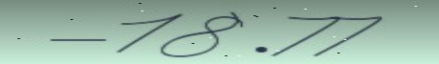

In [60]:
Image.fromarray(cv2.resize(img1,(439,64)))

In [61]:
img1.shape

(67, 199, 3)

In [62]:
import torch.nn.functional as F

In [63]:
chars = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"

char_to_idx = {c: i for i, c in enumerate(chars)}
blank_idx = len(chars)  # 26

In [64]:
char_to_idx["<bos>"] = len(char_to_idx)
char_to_idx["<eos>"] = len(char_to_idx)


In [65]:
char_to_idx

{'A': 0,
 'B': 1,
 'C': 2,
 'D': 3,
 'E': 4,
 'F': 5,
 'G': 6,
 'H': 7,
 'I': 8,
 'J': 9,
 'K': 10,
 'L': 11,
 'M': 12,
 'N': 13,
 'O': 14,
 'P': 15,
 'Q': 16,
 'R': 17,
 'S': 18,
 'T': 19,
 'U': 20,
 'V': 21,
 'W': 22,
 'X': 23,
 'Y': 24,
 'Z': 25,
 '<bos>': 26,
 '<eos>': 27}

In [66]:
pad_id = tokenizer.token_to_id("<pad>")
bos_id = tokenizer.token_to_id("<bos>")
eos_id = tokenizer.token_to_id("<eos>")
unk_id = tokenizer.token_to_id("<unk>")


In [67]:
tokenizer.get_vocab_size()

10000

### we will use shape : (x,64),height:64,width: depends on batch 

In [68]:
class Makeset(Dataset):
    def __init__(self,images,labels, height=32):
        self.images = images 
        self.labels = labels
        self.height = height
        self.images = np.array(self.images)
        self.labels = np.array(self.labels)
        
        self.transform = v2.Compose([
            v2.ToImage(),
            v2.ToDtype(torch.float32, scale=True),
            v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ]) 
    def __getitem__(self,idx):
        label = self.labels[idx]
        image = self.images[idx]
        image = Image.open(image).convert("RGB")
        label = tokenizer.encode(label).ids
        
        label = [bos_id] + label + [eos_id]
        w, h = image.size
        new_h = self.height
        new_w = max(1, int(w * new_h / h))
        image = v2.Resize((new_h, new_w))(image)
        image = self.transform(image)
        label = torch.tensor(label,dtype=torch.long)
        return image,label[:-1],label[1:]
    def __len__(self):
        return len(self.images)



In [69]:
from sklearn.model_selection import train_test_split 

In [70]:
data =  pd.read_csv('label.csv', keep_default_na=False)

In [71]:
data

,Unnamed: 0,img_name,label
0,0,02_01_2018@synthv2_1234_0000000.jpg,02/01/2018
1,1,gr_s@synthv2_1234_0000001.jpg,grès
2,2,Strategists@synthv2_1234_0000002.jpg,Strategists
3,3,incarc_r_tes@synthv2_1234_0000003.jpg,incarcérâtes
4,4,carita401_mac.com@synthv2_1234_0000004.jpg,carita401@mac.com
...,...,...,...
609996,6245,a2___b2___c2@synthv2_12354_0006245.jpg,a2 + b2 = c2
609997,6246,tyls_t@synthv2_12354_0006246.jpg,tylsät
609998,6247,chrystal.ashlie_live.ca@synthv2_12354_0006247.jpg,chrystal.ashlie@live.ca
609999,6248,App_teront@synthv2_12354_0006248.jpg,Appéteront


In [72]:
train_images,test_images,train_labels,test_labels = train_test_split(data['img_name'],data['label'],test_size = 0.05,random_state=42)

In [73]:
train_labels

125887                                Desiree
107570                   auberta.carey@qq.com
458265                              frigidity
134478    http://www.safety.google/components
262009                                      H
                         ...                 
110268                               $135,941
259178                              Textlänge
365838                                výživné
131932                                 vzácně
121958                                    LEÍ
Name: label, Length: 579500, dtype: str

In [74]:
from torch.nn.utils.rnn import pad_sequence

In [75]:
pad_id

0

In [76]:

def collate_fn(batch):
    images, label1, label2 = zip(*batch)



    label1 = pad_sequence(label1, batch_first=True, padding_value=pad_id)
    label2 = pad_sequence(label2, batch_first=True, padding_value=pad_id)

    batch_size = len(images)
    c = images[0].shape[0]
    h = images[0].shape[1]
    max_w = max(img.shape[2] for img in images)

    new_images = images[0].new_zeros((batch_size, c, h, max_w))

    for i, img in enumerate(images):
        w = img.shape[2]
        new_images[i, :, :, :w] = img

    return new_images, label1, label2

In [77]:
629 * 32

20128

In [78]:
train_labels

125887                                Desiree
107570                   auberta.carey@qq.com
458265                              frigidity
134478    http://www.safety.google/components
262009                                      H
                         ...                 
110268                               $135,941
259178                              Textlänge
365838                                výživné
131932                                 vzácně
121958                                    LEÍ
Name: label, Length: 579500, dtype: str

In [79]:
len(char_to_idx) + 1

29

In [80]:
import math
class PositionalEncoding(nn.Module):
    def __init__(self,d_model,max_len):
        super().__init__()
        pe = torch.zeros(max_len,d_model)

        position = torch.arange(0,max_len,dtype=torch.float32).unsqueeze(1)
        
        div_term = torch.exp(
            torch.arange(0,d_model,2,dtype=torch.float32   ) * (-1) * math.log(10000)/d_model
        )

        pe[:,::2] = torch.sin(div_term * position)
        pe[:,1::2] = torch.cos(div_term * position)
        pe = pe.unsqueeze(0)

        self.register_buffer("pe",pe)
        
    def forward(self,x):
        return x + self.pe[:,:x.size(1),:]

        

In [81]:
from torchvision import models

In [82]:
help(models.vision_transformer)

Help on module torchvision.models.vision_transformer in torchvision.models:

NAME
    torchvision.models.vision_transformer

CLASSES
    torch.nn.modules.module.Module(builtins.object)
        VisionTransformer
    torchvision.models._api.WeightsEnum(enum.Enum)
        ViT_B_16_Weights
        ViT_B_32_Weights
        ViT_H_14_Weights
        ViT_L_16_Weights
        ViT_L_32_Weights
    
    class ViT_B_16_Weights(torchvision.models._api.WeightsEnum)
     |  ViT_B_16_Weights(value, names=None, *, module=None, qualname=None, type=None, start=1, boundary=None)
     |  
     |  Method resolution order:
     |      ViT_B_16_Weights
     |      torchvision.models._api.WeightsEnum
     |      enum.Enum
     |      builtins.object
     |  
     |  Data and other attributes defined here:
     |  
     |  IMAGENET1K_SWAG_E2E_V1 = ViT_B_16_Weights.IMAGENET1K_SWAG_E2E_V1
     |  
     |  IMAGENET1K_SWAG_LINEAR_V1 = ViT_B_16_Weights.IMAGENET1K_SWAG_LINEAR_V1
     |  
     |  IMAGENET1K_V1 = ViT_B

In [83]:
help(models.ViT_B_32_Weights)

Help on class ViT_B_32_Weights in module torchvision.models.vision_transformer:

class ViT_B_32_Weights(torchvision.models._api.WeightsEnum)
 |  ViT_B_32_Weights(value, names=None, *, module=None, qualname=None, type=None, start=1, boundary=None)
 |  
 |  Method resolution order:
 |      ViT_B_32_Weights
 |      torchvision.models._api.WeightsEnum
 |      enum.Enum
 |      builtins.object
 |  
 |  Data and other attributes defined here:
 |  
 |  IMAGENET1K_V1 = ViT_B_32_Weights.IMAGENET1K_V1
 |  
 |  ----------------------------------------------------------------------
 |  Data descriptors inherited from enum.Enum:
 |  
 |  name
 |      The name of the Enum member.
 |  
 |  value
 |      The value of the Enum member.
 |  
 |  ----------------------------------------------------------------------
 |  Static methods inherited from enum.EnumType:
 |  
 |  __contains__(member)
 |      Return True if member is a member of this enum
 |      raises TypeError if member is not an enum member
 

In [84]:
models.vit_b_32(weights=models.ViT_B_32_Weights.IMAGENET1K_V1 )

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

In [85]:
class ResidualBlock(nn.Module):
    def __init__(self,in_,out_,stride_=1):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_,out_,kernel_size=3,stride=stride_,padding=1),
            nn.BatchNorm2d(out_),
            nn.ReLU(),
        )

        self.relu = nn.ReLU()
        self.conv2 = nn.Sequential(
            nn.Conv2d(out_,out_,kernel_size=3,stride=1,padding=1),
            nn.BatchNorm2d(out_),
        )

        self.id = nn.Identity()
        if in_ != out_ or stride_ != 1:
            self.id = nn.Sequential(
            nn.Conv2d(in_,out_,kernel_size=1,stride=stride_),
            nn.BatchNorm2d(out_),
        )
    def forward(self,x):
        identity = self.id(x)
        x = self.conv1(x)
        x = self.conv2(x)
        x = x + identity
        x = self.relu(x)
        return x 


In [86]:
device =torch.device("cuda")
class SOCRATE(nn.Module):
    def __init__(self,d_model,max_len,nhead,dim_feedforward,activation,norm_first,num_layers):
        super().__init__()
        self.convolution = nn.Sequential(
            ResidualBlock(3,32,2),
            ResidualBlock(32,64),
            ResidualBlock(64,128,2),
            ResidualBlock(128,256),
            ResidualBlock(256,d_model,2),

        )
        self.project = nn.Sequential(
            nn.Linear(d_model * 4,d_model),
            nn.LayerNorm(d_model),
        )
        self.pool = nn.AdaptiveAvgPool2d((4,None))
        self.pe = PositionalEncoding(d_model,max_len)
        self.norm_image = nn.LayerNorm(d_model)
        self.embedding = nn.Embedding(tokenizer.get_vocab_size(),d_model,padding_idx=pad_id)

        encoder_layer =nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead,dim_feedforward =dim_feedforward,batch_first=True,norm_first =True,activation = "gelu")
        self.encoder = nn.TransformerEncoder(encoder_layer,num_layers=num_layers)

        decoder_layer = nn.TransformerDecoderLayer(d_model=d_model, nhead=nhead,dim_feedforward =dim_feedforward,batch_first=True,norm_first =True,activation = "gelu")
        self.decoder = nn.TransformerDecoder(decoder_layer,num_layers=num_layers)

        self.output = nn.Linear(d_model,tokenizer.get_vocab_size())
        self.last_norm = nn.LayerNorm(d_model)
        self.d_model = d_model 

    def forward(self,image,text):
        image = self.convolution(image)
        image = self.pool(image)
        B,C,H,W = image.shape
        image = image.permute(0, 3, 1, 2).contiguous()
        image = image.view(B,W,C*H)
        image = self.project(image)
        

        image = self.pe(image)
        image = self.encoder(image)
        #text :

        tgt_key_padding_mask = (text == pad_id)
        tgt_mask = nn.Transformer.generate_square_subsequent_mask(text.size(1)).to(device)
        text = self.embedding(text)
        text = self.pe(text * math.sqrt(self.d_model))
        output = self.decoder(text,image,tgt_key_padding_mask =tgt_key_padding_mask ,tgt_mask =tgt_mask)
        output = self.last_norm(output)

        return self.output(output)



        


        



In [87]:
char_to_idx

{'A': 0,
 'B': 1,
 'C': 2,
 'D': 3,
 'E': 4,
 'F': 5,
 'G': 6,
 'H': 7,
 'I': 8,
 'J': 9,
 'K': 10,
 'L': 11,
 'M': 12,
 'N': 13,
 'O': 14,
 'P': 15,
 'Q': 16,
 'R': 17,
 'S': 18,
 'T': 19,
 'U': 20,
 'V': 21,
 'W': 22,
 'X': 23,
 'Y': 24,
 'Z': 25,
 '<bos>': 26,
 '<eos>': 27}

In [88]:
#using __name__ just so I can use windows num_workers 

In [89]:
len(char_to_idx)

28

In [91]:
import os
import torch
from tqdm import tqdm

def train(model, dataloader, optimizer, scheduler, criterion, device, best_loss):
    model.train()
    total_loss = 0.0
    pbar = tqdm(dataloader)

    for step, (image, t1, t2) in enumerate(pbar, 1):
        image = image.to(device, non_blocking=True)
        t1 = t1.to(device, non_blocking=True)
        t2 = t2.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        output = model(image, t1)

        loss = criterion(
            output.reshape(-1, output.size(-1)),
            t2.reshape(-1)
        )

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()
        avg_loss = total_loss / step

        pbar.set_postfix(
            loss=f"{loss.item():.4f}",
            avg_loss=f"{avg_loss:.4f}",
            best=f"{best_loss:.4f}"
        )

        if step % 100 == 0:
            checkpoint = {
                "model": model.state_dict(),
                "optimizer": optimizer.state_dict(),
                "scheduler": scheduler.state_dict(),
                "best_loss": best_loss,
                "avg_loss": avg_loss,
                "step": step,
            }
            torch.save(checkpoint, "previous.pt")

            if avg_loss < best_loss:
                best_loss = avg_loss
                checkpoint["best_loss"] = best_loss
                torch.save(checkpoint, "best.pt")

    print(f"Train Loss: {total_loss / len(dataloader):.4f}")
    return best_loss



if __name__ == '__main__':
    
    dataloader = DataLoader(
    Makeset([f"handwritten-data/synthetic-data/{i}" for i in train_images], train_labels),
    batch_size=128,
    shuffle=True,
    pin_memory=True,
    collate_fn=collate_fn
    
   
)

    
    model = SOCRATE(
        d_model=640,
        max_len=512,
        nhead=10,
        dim_feedforward=2560,
        activation="gelu",
        norm_first=True,
        num_layers=12
    ).to(device)
    
    criterion = nn.CrossEntropyLoss(ignore_index=pad_id, label_smoothing=0.05)

    optimizer = optim.AdamW(
        model.parameters(),
        lr=5e-5,
        betas=(0.9, 0.95),
        weight_decay=1e-2
    )
    
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, 50)
    
    best_loss = float("inf")
    
    if os.path.exists("previous.pt"):
        ckpt = torch.load("previous.pt", map_location=device)
        model.load_state_dict(ckpt["model"])
        optimizer.load_state_dict(ckpt["optimizer"])
        scheduler.load_state_dict(ckpt["scheduler"])
        best_loss = ckpt["best_loss"]
        print("Checkpoint inc.")

    for i in range(20):
        best_loss = train(model, dataloader, optimizer, scheduler, criterion, device, best_loss)
        scheduler.step()


c:\Users\kenyp\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
C:\Users\kenyp\AppData\Local\Temp\ipykernel_29208\891774140.py:94: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you sta

Checkpoint inc.


  0%|          | 0/4528 [00:11<?, ?it/s]


KeyboardInterrupt: 

In [92]:
char_to_idx["<bos>"]

26

In [93]:
testloader = DataLoader(
    Makeset([f"handwritten-data/synthetic-data/{i}" for i in test_images],test_labels),shuffle=False,batch_size = 1,pin_memory=True,collate_fn=collate_fn
)

In [94]:
@torch.no_grad()
def generate(image,temp=0.5,max_iter = 64,penalty=1.15):

    current_text = [bos_id]
    generated = []
    already_seen = set()
    for i in range(max_iter):
        x = torch.tensor([current_text],dtype=torch.long).to(device)
        output = model(image,x)
        output = output[:,-1,:]
        for token_id in already_seen:
            if output[0, token_id] < 0:
                    output[0, token_id] *= penalty
            else:
                    output[0, token_id] /= penalty
        output = output / temp
        topk_vals, topk_idx = torch.topk(output, 5, dim=-1)
        probs  = F.softmax(topk_vals,dim = -1)
        idx = torch.multinomial(probs,1)

        idx = topk_idx.gather(-1,idx).item()
        if(idx == eos_id):
            break

        generated.append(idx)
        current_text.append(idx)
        already_seen.add(idx)

    return generated


In [95]:
@torch.inference_mode()
def generate_fast(image, max_iter=32, stop_repeats=4):
    model.eval()

    bos = bos_id
    eos = eos_id

    current_text = [bos]
    generated = []

    for _ in range(max_iter):
        x = torch.tensor([current_text], dtype=torch.long, device=device)

        output = model(image, x)
        logits = output[:, -1, :]

        idx = logits.argmax(dim=-1).item()

        if idx == eos:
            break

        generated.append(idx)
        current_text.append(idx)

        if len(generated) >= stop_repeats:
            last = generated[-stop_repeats:]
            if len(set(last)) == 1:
                break

    return generated

In [96]:
idx_to_char = {v: k for k, v in char_to_idx.items()}

In [97]:
test_images


548399           letisk@synthv2_12345_0000898.jpg
474089       0241_863294@synthv2_1234_0474089.jpg
443033       MITREFLOWER@synthv2_1234_0443033.jpg
597416            pet_t@synthv2_12352_0006165.jpg
405711      0786_187_591@synthv2_1234_0405711.jpg
                           ...                   
142046          do_ruluk@synthv2_1234_0142046.jpg
406170           981_684@synthv2_1234_0406170.jpg
221919     f_L-jv0OM_0nb@synthv2_1234_0221919.jpg
307240    Derivationally@synthv2_1234_0307240.jpg
131020         g_reteket@synthv2_1234_0131020.jpg
Name: img_name, Length: 30501, dtype: str

In [98]:
test_images[:30]

548399                     letisk@synthv2_12345_0000898.jpg
474089                 0241_863294@synthv2_1234_0474089.jpg
443033                 MITREFLOWER@synthv2_1234_0443033.jpg
597416                      pet_t@synthv2_12352_0006165.jpg
405711                0786_187_591@synthv2_1234_0405711.jpg
294225                  Xy4u3Y__cu@synthv2_1234_0294225.jpg
170903                  monstr_sem@synthv2_1234_0170903.jpg
169181    cathi.cassaundra_rocketmail.com@synthv2_1234_0...
239498             U4359t_JwH1G_SK@synthv2_1234_0239498.jpg
608983             xo_cTxjnZ8qTM6@synthv2_12354_0005232.jpg
534755                     distil@synthv2_12342_0006004.jpg
506694                    h_lm_ksi@synthv2_1234_0006694.jpg
34429                        l_gua@synthv2_1234_0034429.jpg
250750                     famular@synthv2_1234_0250750.jpg
182766    Paseo_Krasnoye_Selo_91__Ap._82@synthv2_1234_01...
420264               KATAKINETOMER@synthv2_1234_0420264.jpg
423018                  01.08.2015@synth

In [105]:
import os
import torch
from tqdm import tqdm

@torch.no_grad()
def eval():
    global best_loss

    model.eval()
    total_loss = 0.0

    pbar = tqdm(testloader)

    for step, (image, t1, t2) in enumerate(pbar, 1):
        image = image.to(device)
        t1 = t1.to(device)
        t2 = t2.to(device)
        idk = generate(image, max_iter=64,penalty=1.25,temp=0.01)
        
        idk = [tokenizer.decode([i]) for i in idk]
        idk2 = [
    tokenizer.decode([x.item()])
    for x in t1[0]
    if x.item() != pad_id
]
        print(f"generated: {''.join(idk)} real: {''.join(idk2)} |")
        if(step == 128):
            break
        
        
        
        
eval()

  0%|          | 2/30501 [00:00<2:02:28,  4.15it/s]

generated: letská real: letiská |
generated: 0241863294 real: 0241863294 |


  0%|          | 4/30501 [00:00<1:45:12,  4.83it/s]

generated: MTREFLOWER real: MITREFLOWER |
generated: płała real: petät |


  0%|          | 5/30501 [00:01<1:49:10,  4.66it/s]

...

generated: htww.mashable.com/Do real: http://www.mashable.com/DoInfo |
generated: LibG$XR real: Li3bG$XR |


  0%|          | 127/30501 [00:26<1:37:16,  5.20it/s]

generated: decuplerais real: décuplerais |
generated: ESTED real: esterified |


  0%|          | 127/30501 [00:27<1:48:09,  4.68it/s]

generated: aterizăm real: aterizăm |
